In [1]:
from torchvision import datasets, transforms
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import time
import os

import warnings
warnings.filterwarnings("ignore")

os.environ["VSLANG"] = "1033"

In [2]:
# Загружаем данные MNIST без преобразований (только ToTensor)
transform = transforms.Compose([
    # Внимание! В этом случае для изображений значения приводятся к дмиапазону [0;1]
    # Но видна эта трансформация будет только при работе с DataLoader, т.е. она отложенная
    transforms.ToTensor()  # Преобразует изображение в тензор
])

# Загружаем тренировочный датасет
# train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_dataset = datasets.MNIST(root='../18_Neural_learning_problems/MNIST_data', train=True, download=True, transform=transform)

# Создаем DataLoader для итерации по данным
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=False)

In [3]:
# Инициализируем переменные для вычисления среднего и std
mean = 0.0
std = 0.0
total_samples = 0

# Вычисляем среднее
for images, _ in train_loader:
    batch_samples = images.size(0)  # Количество изображений в батче
    images = images.view(batch_samples, images.size(1), -1)  # Преобразуем в [batch_size, channels, height*width]
    # Размерность 2 - "плоское" изображение, т.е. среднее считается по пикселям
    mean += images.mean(2).sum(0)  # Суммируем среднее по всем изображениям в батче
    total_samples += batch_samples

mean /= total_samples  # Делим на общее количество изображений

# Вычисляем стандартное отклонение
for images, _ in train_loader:
    batch_samples = images.size(0)
    images = images.view(batch_samples, images.size(1), -1)
    # sum([0, 2]) - суммирование по двум измерениям сразу, сначала каждый пиксель по всему батчу, затем сумма всех аггрегированных
    # эквивалентно .sum(0).sum(1)
    std += ((images - mean.unsqueeze(1)) ** 2).sum([0, 2])  # Суммируем квадраты отклонений

std = torch.sqrt(std / (total_samples * 28 * 28))  # Делим на общее количество пикселей

print("Mean:", mean.item())
print("Std:", std.item())

Mean: 0.13066041469573975
Std: 0.30810800194740295


In [88]:
examples = enumerate(train_loader)
batch_idx, (expample, label) = next(examples)
print(expample.data[0])

tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,

In [89]:
print(expample.shape)
batch_size = expample.size(0)
example_flat = expample.view(batch_size, expample.size(1), -1)
print(example_flat.shape)
# print(example_flat[0][0])
mean = example_flat.mean(2)
print(mean.shape)
mean = mean.sum(0)
print(mean)
print(mean.unsqueeze(1))
std = ((example_flat - mean) ** 2)
print(std.shape)
print(std)
print(std.sum(0).shape)
print(std.sum(0))
print(std.sum(0).sum(1))
print(std.sum([0,2]))

torch.Size([64, 1, 28, 28])
torch.Size([64, 1, 784])
torch.Size([64, 1])
tensor([8.1145])
tensor([[8.1145]])
torch.Size([64, 1, 784])
tensor([[[65.8447, 65.8447, 65.8447,  ..., 65.8447, 65.8447, 65.8447]],

        [[65.8447, 65.8447, 65.8447,  ..., 65.8447, 65.8447, 65.8447]],

        [[65.8447, 65.8447, 65.8447,  ..., 65.8447, 65.8447, 65.8447]],

        ...,

        [[65.8447, 65.8447, 65.8447,  ..., 65.8447, 65.8447, 65.8447]],

        [[65.8447, 65.8447, 65.8447,  ..., 65.8447, 65.8447, 65.8447]],

        [[65.8447, 65.8447, 65.8447,  ..., 65.8447, 65.8447, 65.8447]]])
torch.Size([1, 784])
tensor([[4214.0620, 4214.0620, 4214.0620, 4214.0620, 4214.0620, 4214.0620,
         4214.0620, 4214.0620, 4214.0620, 4214.0620, 4214.0620, 4214.0620,
         4214.0620, 4214.0620, 4214.0620, 4214.0620, 4214.0620, 4214.0620,
         4214.0620, 4214.0620, 4214.0620, 4214.0620, 4214.0620, 4214.0620,
         4214.0620, 4214.0620, 4214.0620, 4214.0620, 4214.0620, 4214.0620,
         4214.0620

In [92]:
train_dataset.data[0]

tensor([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,  18,
          18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   

In [72]:
mean = train_dataset.data.float().mean() 
std = train_dataset.data.float().std() 
print(mean/255)
print(std/255)

tensor(0.1307)
tensor(0.3081)


In [3]:
# Определяем модель
class FCNN(nn.Module):
    def __init__(self):
        super(FCNN, self).__init__()
        self.fc1 = nn.Linear(28 * 28, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)

    def forward(self, x):
        x = x.view(-1, 28 * 28)  # Преобразуем изображение в вектор
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [4]:
# Преобразования для данных
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Загружаем данные
# train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_dataset = datasets.MNIST(root='../18_Neural_learning_problems/MNIST_data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

In [5]:
!"D:\Apps\Microsoft Visual Studio\18\Community\VC\Auxiliary\Build\vcvarsall.bat " x64

**********************************************************************
** Visual Studio 2026 Developer Command Prompt v18.3.0
** Copyright (c) 2025 Microsoft Corporation
**********************************************************************
[vcvarsall.bat] Environment initialized for: 'x64'


In [5]:
# Инициализация модели, функции потерь и оптимизатора
model = FCNN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Функция для обучения
def train(model, train_loader, criterion, optimizer, device='cpu', compiled=False):
    model.to(device)
    model.train()
    total_loss = 0
    start_time = time.time()

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    end_time = time.time()
    print(f"Compiled: {compiled}, Loss: {total_loss / len(train_loader)}, Time: {end_time - start_time:.4f} seconds")

# Обучение без компиляции
print("Без использования torch.compile():")
train(model, train_loader, criterion, optimizer, device='cpu', compiled=False)

# Обучение с компиляцией
# torch._dynamo.reset()
print("С использованием torch.compile() default:")
# Компиляция модели с torch.compile()
compiled_model = torch.compile(model)
train(compiled_model, train_loader, criterion, optimizer, device='cpu', compiled=True)
print("С использованием torch.compile() reduce-overhead:")
compiled_model = torch.compile(model, mode="reduce-overhead")
train(compiled_model, train_loader, criterion, optimizer, device='cpu', compiled=True)
print("С использованием torch.compile() max-autotune:")
compiled_model = torch.compile(model, mode="max-autotune")
train(compiled_model, train_loader, criterion, optimizer, device='cpu', compiled=True)

Без использования torch.compile():
Compiled: False, Loss: 0.27214920370460255, Time: 4.6644 seconds
С использованием torch.compile() default:


InductorError: CppCompileError: C++ compile error

Command:
cl /I d:/Apps/Anaconda3/envs/otus-ml/Include /I d:/Apps/Anaconda3/envs/otus-ml/Lib/site-packages/torch/include /I d:/Apps/Anaconda3/envs/otus-ml/Lib/site-packages/torch/include/torch/csrc/api/include /D NOMINMAX /D TORCH_INDUCTOR_CPP_WRAPPER /D STANDALONE_TORCH_HEADER /D C10_USING_CUSTOM_GENERATED_MACROS /O2 /DLL /MD /std:c++20 /wd4819 /wd4251 /wd4244 /wd4267 /wd4275 /wd4018 /wd4190 /wd4624 /wd4067 /wd4068 /EHsc /Zc:__cplusplus /permissive- /openmp /openmp:experimental C:/Users/MAZURE~1/AppData/Local/Temp/torchinductor_MazurenkoEV/nq/cnq3pwyor3qteithxksc63wu43hovoygwapzoqyb6tcy6jk6sqsb.main.cpp /FeC:/Users/MAZURE~1/AppData/Local/Temp/torchinductor_MazurenkoEV/nq/cnq3pwyor3qteithxksc63wu43hovoygwapzoqyb6tcy6jk6sqsb.main.pyd /LD /link /LIBPATH:d:/Apps/Anaconda3/envs/otus-ml/libs /LIBPATH:d:/Apps/Anaconda3/envs/otus-ml/Lib/site-packages/torch/lib torch.lib torch_cpu.lib torch_python.lib sleef.lib

Output:
Microsoft (R) C/C++ Opti

In [10]:
device = 'cuda:0' if torch.cuda.is_available() else 'cpu' # поставить cuda:0
print(f"Using device: {device}")

Using device: cuda:0


In [11]:
model = FCNN().to(device)

In [13]:
# Загружаем данные
train_dataset = datasets.MNIST(root='../18_Neural_learning_problems/MNIST_data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, pin_memory=True)

In [9]:
train(model, train_loader, criterion, optimizer, device=device, compiled=False)
compiled_model = torch.compile(model)
train(compiled_model, train_loader, criterion, optimizer, device=device, compiled=True)
compiled_model = torch.compile(model, mode="reduce-overhead")
train(compiled_model, train_loader, criterion, optimizer, device=device, compiled=True)
compiled_model = torch.compile(model, mode="max-autotune")
train(compiled_model, train_loader, criterion, optimizer, device=device, compiled=True)

Compiled: False, Loss: 2.314808305646819, Time: 13.1111 seconds


W1210 12:25:35.808000 318 torch/_inductor/utils.py:1558] [0/4] Not enough SMs to use max_autotune_gemm mode


Compiled: True, Loss: 2.314801847502621, Time: 18.8627 seconds
Compiled: True, Loss: 2.314805548582504, Time: 13.5513 seconds


Autotune Choices Stats:
{"num_choices": 2, "num_triton_choices": 0, "best_kernel": "addmm", "best_time": 0.02022399939596653}
AUTOTUNE addmm(64x10, 64x64, 64x10)
strides: [0, 1], [64, 1], [1, 64]
dtypes: torch.float32, torch.float32, torch.float32
  addmm 0.0202 ms 100.0% 
  bias_addmm 0.0653 ms 31.0% 
SingleProcess AUTOTUNE benchmarking takes 0.0321 seconds and 0.0001 seconds precompiling for 2 choices


Compiled: True, Loss: 2.3147953664824397, Time: 17.2537 seconds


на gpu прирост прозводительности для такой модели не является существенным

Шедуллинг (scheduling) в PyTorch

100%|██████████| 9.91M/9.91M [00:20<00:00, 490kB/s] 
100%|██████████| 28.9k/28.9k [00:00<00:00, 163kB/s]
100%|██████████| 1.65M/1.65M [00:02<00:00, 779kB/s] 
100%|██████████| 4.54k/4.54k [00:00<00:00, 4.54MB/s]


Training with scheduler:
Epoch [1/10], Loss: 0.2681, LR: 0.001000
Epoch [2/10], Loss: 0.1141, LR: 0.001000
Epoch [3/10], Loss: 0.0821, LR: 0.001000
Epoch [4/10], Loss: 0.0641, LR: 0.001000
Epoch [5/10], Loss: 0.0514, LR: 0.000100
Epoch [6/10], Loss: 0.0231, LR: 0.000100
Epoch [7/10], Loss: 0.0169, LR: 0.000100
Epoch [8/10], Loss: 0.0145, LR: 0.000100
Epoch [9/10], Loss: 0.0128, LR: 0.000100
Epoch [10/10], Loss: 0.0113, LR: 0.000010
Training without scheduler:
Epoch [1/10], Loss: 0.0377, LR: 0.001000
Epoch [2/10], Loss: 0.0318, LR: 0.001000
Epoch [3/10], Loss: 0.0290, LR: 0.001000
Epoch [4/10], Loss: 0.0238, LR: 0.001000
Epoch [5/10], Loss: 0.0224, LR: 0.001000
Epoch [6/10], Loss: 0.0189, LR: 0.001000
Epoch [7/10], Loss: 0.0177, LR: 0.001000
Epoch [8/10], Loss: 0.0176, LR: 0.001000
Epoch [9/10], Loss: 0.0185, LR: 0.001000
Epoch [10/10], Loss: 0.0125, LR: 0.001000


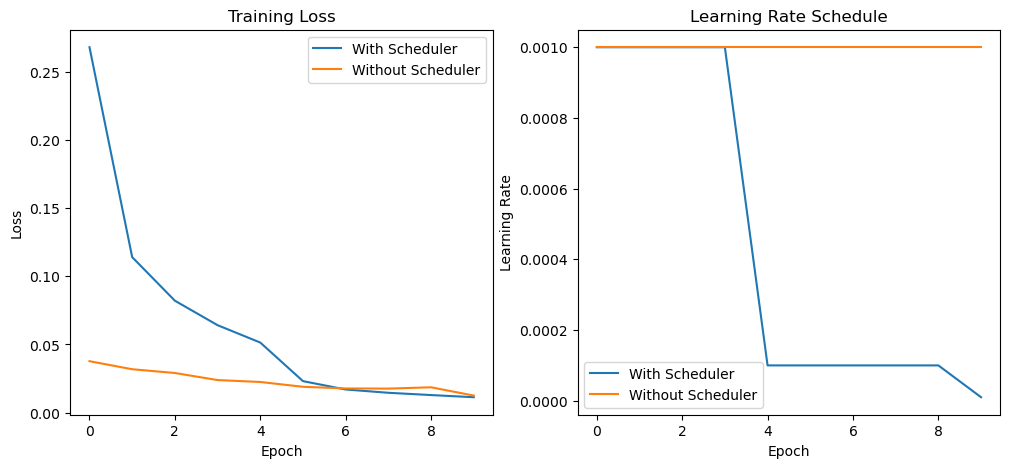

In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# Определяем модель
class FCNN(nn.Module):
    def __init__(self):
        super(FCNN, self).__init__()
        self.fc1 = nn.Linear(28 * 28, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)

    def forward(self, x):
        x = x.view(-1, 28 * 28)  # Преобразуем изображение в вектор
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# Загрузка данных
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST(root='../18_Neural_learning_problems/MNIST_data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

test_dataset = datasets.MNIST(root='.../18_Neural_learning_problems/MNIST_data', train=False, download=True, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# Инициализация модели, функции потерь и оптимизатора
model = FCNN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Шедуллер для уменьшения скорости обучения
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)  # Уменьшаем LR каждые 5 эпох в 10 раз

# Функция для обучения
def train(model, train_loader, criterion, optimizer, scheduler=None, num_epochs=1):
    model.train()
    losses = []
    learning_rates = []

    for epoch in range(num_epochs):
        epoch_loss = 0
        for images, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        if scheduler:
            scheduler.step()  # Обновляем скорость обучения

        losses.append(epoch_loss / len(train_loader))
        learning_rates.append(optimizer.param_groups[0]['lr'])  # Сохраняем текущий LR
        print(f"Epoch [{epoch + 1}/{num_epochs}], Loss: {epoch_loss / len(train_loader):.4f}, LR: {learning_rates[-1]:.6f}")

    return losses, learning_rates

# Обучаем модель с шедуллером
print("Training with scheduler:")
losses_with_scheduler, lrs_with_scheduler = train(model, train_loader, criterion, optimizer, scheduler, num_epochs=10)

# Обучаем модель без шедуллера (для сравнения)
optimizer_no_scheduler = optim.Adam(model.parameters(), lr=0.001)
print("Training without scheduler:")
losses_without_scheduler, lrs_without_scheduler = train(model, train_loader, criterion, optimizer_no_scheduler, num_epochs=10)

# Визуализация результатов
plt.figure(figsize=(12, 5))

# График потерь
plt.subplot(1, 2, 1)
plt.plot(losses_with_scheduler, label='With Scheduler')
plt.plot(losses_without_scheduler, label='Without Scheduler')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.legend()

# График скорости обучения
plt.subplot(1, 2, 2)
plt.plot(lrs_with_scheduler, label='With Scheduler')
plt.plot(lrs_without_scheduler, label='Without Scheduler')
plt.xlabel('Epoch')
plt.ylabel('Learning Rate')
plt.title('Learning Rate Schedule')
plt.legend()

plt.show()

In [11]:
# Уменьшает скорость обучения, если потери перестают улучшаться.
# scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=2)

# Изменяет скорость обучения по косинусоидальному закону.
# scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

# Использует одну циклическую политику изменения скорости обучения.
# scheduler = optim.lr_scheduler.OneCycleLR(optimizer, max_lr=0.01, total_steps=100)

Модуль хуков в PyTorch

In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [13]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2)
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)
        x = x.view(-1, 64 * 7 * 7)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

Хук — это функция, которая будет вызываться во время прямого или обратного прохода. Например, можно создать хук для сохранения активаций сверточного слоя:

In [14]:
# описание хука
activations = {}
def hook_fn(module, input, output):
    activations['conv1'] = output

In [15]:
model = CNN()
# регистрация хука
hook_handle = model.conv1.register_forward_hook(hook_fn) # регистрация хука

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST(root='../18_Neural_learning_problems/MNIST_data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

test_dataset = datasets.MNIST(root='../18_Neural_learning_problems/MNIST_data', train=False, download=True, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [17]:
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

for epoch in range(1):  # 1 эпоха для наглядности
    model.train()
    for batch_idx, (data, target) in enumerate(train_loader):
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()

        if batch_idx % 100 == 0:
            print(f'Epoch: {epoch}, Batch: {batch_idx}, Loss: {loss.item()}')
            print(f'Activations: {activations["conv1"].shape}')

Epoch: 0, Batch: 0, Loss: 2.28185772895813
Activations: torch.Size([64, 32, 28, 28])
Epoch: 0, Batch: 100, Loss: 0.6430224180221558
Activations: torch.Size([64, 32, 28, 28])
Epoch: 0, Batch: 200, Loss: 0.07429635524749756
Activations: torch.Size([64, 32, 28, 28])
Epoch: 0, Batch: 300, Loss: 0.11740134656429291
Activations: torch.Size([64, 32, 28, 28])
Epoch: 0, Batch: 400, Loss: 0.045573074370622635
Activations: torch.Size([64, 32, 28, 28])
Epoch: 0, Batch: 500, Loss: 0.014901168644428253
Activations: torch.Size([64, 32, 28, 28])
Epoch: 0, Batch: 600, Loss: 0.07155150920152664
Activations: torch.Size([64, 32, 28, 28])
Epoch: 0, Batch: 700, Loss: 0.019848715513944626
Activations: torch.Size([64, 32, 28, 28])
Epoch: 0, Batch: 800, Loss: 0.011802449822425842
Activations: torch.Size([64, 32, 28, 28])
Epoch: 0, Batch: 900, Loss: 0.06159442290663719
Activations: torch.Size([64, 32, 28, 28])


In [18]:
# можем видеть как изменялся тензор сигнала с выхода слоя activations["conv1"]